In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("../")

In [3]:
from ease_recommender import *
from npmi_recommender import *

import pickle as p

In [4]:
def create_mat(row, col, bool_to_int=True):
    # bool_to_int won't count duplicates in the same row, creates a different weighting basically
    if bool_to_int:
        data = np.ones_like(row, dtype=bool)
        return csr_matrix((data, (row, col))).astype(np.int64)
    else:
        data = np.ones_like(row, dtype=np.int64)
        return csr_matrix((data, (row, col)))

def check_if_all_terms_in_str(q, terms):
    for term in terms:
        if term not in q:
            return False

    return True

def get_cat2idx(category_type, D):
    if category_type == "track":
        return D["track2idx"]
    elif category_type == "album":
        return D["album2idx"]
    elif category_type == "artist":
        return D["artist2idx"]
    else:
        raise NotImplementedError

def find_match_using_terms(terms, cat2idx):
    matches = []
    for name in cat2idx.keys():
        if check_if_all_terms_in_str(name, terms):
            matches.append(name)

    if len(matches) > 1:
        raise Exception("Multiple matches found, filter down to a single match", matches)

    return matches[0]

In [5]:
print("loading cache data...")
D = p.load(open("cached_data/spotify_preprocessed.p", "rb"))

print("building csr matrices...")

# TODO: finish implementing track and album level recommendations

# track_mat = create_mat(D["playlist_indices"], D["track_indices"])
# album_mat = create_mat(D["playlist_indices"], D["album_indices"])
artist_mat = create_mat(D["playlist_indices"], D["artist_indices"])

print("done")

loading cache data...
building csr matrices...
done


In [6]:
cat2idx = get_cat2idx("artist", D)
idx2cat = {v:k for k, v in cat2idx.items()}

In [7]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412


In [8]:
c_name = find_match_using_terms(["Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)"], cat2idx)
c = cat2idx[c_name]
print(f"{c_name=}")
print(f"Num Rows: {artist_mat[:, c].sum()}")

c_name='Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)'
Num Rows: 71


In [9]:
import numpy as np
from scipy import sparse

def calculate_pmi_matrix(co_counts, alpha=1.0):
    """
    Calculates Alpha-Smoothed PMI for the entire co-occurrence matrix.
    Only computes values for observed entries (non-zeros) to maintain sparsity.
    
    Formula:
    PMI(x,y) = log( (C_xy + alpha) * N_smoothed / (S_x * S_y) )
             = log(C_xy + alpha) + log(N_smoothed) - log(S_x) - log(S_y)
    
    Args:
        co_counts: (n_items, n_items) scipy.sparse matrix (Counts of x, y).
        alpha: Smoothing parameter.
        
    Returns:
        pmi_matrix: (n_items, n_items) scipy.sparse matrix containing PMI values.
    """
    # Ensure we work with a COO matrix to easily access .row, .col, and .data
    # This is a cheap conversion if it's already CSR/CSC
    co_counts_coo = co_counts.tocoo()
    
    n_items = co_counts_coo.shape[0]
    
    # 1. Global Constants
    # Total sum of all counts in the matrix
    N_raw = co_counts_coo.sum()
    
    # Smoothed Normalization Factor: N + alpha * V^2
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 2. Calculate Smoothed Marginals (S_x and S_y)
    # Row sums gives us C_x (raw marginal counts)
    # We flatten it to a dense 1D array for easy lookup
    C_marginal = np.array(co_counts_coo.sum(axis=1)).flatten()
    
    # Apply smoothing to marginals: C_x + alpha * V
    S_marginal = C_marginal + (alpha * n_items)
    
    # 3. Vectorized PMI Calculation on Non-Zero Elements
    # We operate directly on the 'data' array of the sparse matrix.
    
    # rows and cols indices for every non-zero entry
    rows = co_counts_coo.row
    cols = co_counts_coo.col
    
    # Data is C_xy
    C_xy = co_counts_coo.data
    
    # Look up the marginals for every interaction
    # If interaction is (item 5, item 99), we grab S_marginal[5] and S_marginal[99]
    Sx_vals = S_marginal[rows]
    Sy_vals = S_marginal[cols]
    
    # Apply the Log-PMI formula decomposed:
    # log(C_xy + alpha) + log(N_smoothed) - log(Sx) - log(Sy)
    
    term1 = np.log(C_xy + alpha)
    term2 = np.log(N_smoothed)
    term3 = np.log(Sx_vals)
    term4 = np.log(Sy_vals)
    
    pmi_data = term1 + term2 - term3 - term4
    
    # 4. Reconstruct Sparse Matrix
    # We create a new CSR matrix with the calculated PMI values
    pmi_matrix = sparse.csr_matrix(
        (pmi_data, (rows, cols)), 
        shape=co_counts_coo.shape
    )
    
    return pmi_matrix

In [10]:
mat = artist_mat
mat = csr_array(mat)

In [11]:
mat.shape

(1000000, 295860)

In [12]:
X = mat.T @ mat

In [13]:
X.shape

(295860, 295860)

In [86]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0, normalize=False, zero_diag=True, non_neg=False):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    if non_neg:
        sppmi.data = np.where(sppmi.data > 0, sppmi.data, 0)
    
    if zero_diag:
        sppmi.setdiag(np.zeros(sppmi.shape[0]))
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [87]:
alpha = .1 * .85

In [88]:
sppmi = sparse_laplace_sppmi(X, alpha=alpha, non_neg=True)

In [89]:
sppmi.shape

(295860, 295860)

In [90]:
from sklearn.metrics.pairwise import cosine_similarity

# For row i against all rows
similarities = cosine_similarity(sppmi[a:a+1], sppmi)[0]

In [91]:
x = np.argsort(-similarities)[:20]

In [92]:
similarities[x]

array([1.        , 0.78065003, 0.77347397, 0.77097525, 0.76615581,
       0.76569025, 0.76379848, 0.76197351, 0.76195743, 0.75536566,
       0.75443317, 0.75342209, 0.75131001, 0.75115326, 0.74661275,
       0.74524441, 0.74492125, 0.74359321, 0.7423775 , 0.7420821 ])

In [93]:
# cosine_similarity(sppmi[x[0]:x[0]+1, :].toarray(), sppmi[x[1]:x[1]+1, :].toarray())[0][0]

In [73]:
similarities = sppmi[a:a+1] * sppmi

In [77]:
similarities = similarities.sum(axis=1)

In [94]:
# np.argsort(-similarities).tolist().index(c)

In [97]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
Local Natives (spotify:artist:75dQReiBOHN37fQgWQrIAJ)
alt-J (spotify:artist:3XHO7cRUPCLOr6jwp8vsx5)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)
Angus & Julia Stone (spotify:artist:4tvKz56Tr39bkhcQUTO0Xr)
High Highs (spotify:artist:1cXVTtkpqSXVhyD32f9MS4)
Lord Huron (spotify:artist:6ltzsmQQbmdoHHbLZ4ZN25)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Kishi Bashi (spotify:artist:3LVPGE5jPPwtbGslx07YR0)
Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)
Wild Child (spotify:artist:1xLMexpeeTKQ20SwGMaGSK)
Fleet Foxes (spotify:arti

In [102]:
similarities = sppmi[a:a+1] * sppmi
similarities = similarities.sum(axis=1)

In [128]:
max_sim = sppmi.sum(axis=-1)

min_sim = 1

# min_sim = np.where(max_sim < max_sim[a], max_sim[a], max_sim)
# min_sim = np.where(max_sim < max_sim[a], max_sim[a], max_sim)
# min_sum = max_sim * max_sim[a]

In [122]:
similarities2 = similarities / min_sim

In [123]:
for i in np.argsort(-similarities2)[:40]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Conner Youngblood (spotify:artist:1HzpwUIkmmlGCNuoOcXiIW)
Kishi Bashi (spotify:artist:3LVPGE5jPPwtbGslx07YR0)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Bibio (spotify:artist:0qzzGu8qpbXYpzgV52wOFT)
Active Child (spotify:artist:54KTsBl98buzGkELjGlnuU)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)
St. South (spotify:artist:1n3X60xWCyL1zytSiKeu4D)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Andy Shauf (spotify:artist:5mFKYdmiYwNJTDtSzgFyQx)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
The Barr Brothers (spotify:artist:4OyRutd80DZC22C4pl63l7)
Wild Child (spotify:artist:1xLMexpeeTKQ20SwGMaGSK)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
Andrew Bird (spotify:artist:4uSftVc3FPWe6RJuMZNEe9)
SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)
Typhoon (spotify:artist:6p6WlxIkeWH8yOYvciFfVl)
Wildcat! Wildcat! (spotify:artist:75idpsM55NDCel7H06QwKO)
Motopony (spotify:artist:5urVI

In [134]:
ax = X[a].toarray()
ax = ax / ax.sum()

In [135]:
bx = X[b].toarray()
bx = bx / bx.sum()

In [138]:
(ax * bx).sum()

np.float64(0.0005366484081132199)

In [143]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

def get_item_similarities(cooccur_matrix: csr_matrix, item_idx: int) -> np.ndarray:
    """
    Get cosine similarity of item_idx to all other items based on co-occurrence.
    
    Normalizes each row to represent conditional probabilities P(j|i),
    then computes cosine similarity between item_idx and all items.
    
    Returns: (n,) array of similarities
    """
    # Row-normalize to get P(j|i) for each item i
    row_sums = np.array(cooccur_matrix.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1  # avoid division by zero
    
    # Create diagonal matrix for normalization
    row_sums_inv = 1 / row_sums
    normalized = cooccur_matrix.multiply(row_sums_inv[:, np.newaxis]).tocsr()
    
    # Get cosine similarity of item_idx to all items
    item_vec = normalized[item_idx:item_idx+1]  # keep as (1, n) sparse matrix
    similarities = cosine_similarity(item_vec, normalized).flatten()
    
    return similarities

In [148]:
def get_item_similarities_symmetric(cooccur_matrix: csr_matrix, item_idx: int) -> np.ndarray:
    """
    Get cosine similarity of item_idx to all other items with symmetric normalization.
    
    Uses symmetric normalization: count_ij / sqrt(count_i * count_j)
    This is similar to PMI-style normalization and treats co-occurrence symmetrically.
    
    Returns: (n,) array of similarities
    """
    # Get marginal counts (total co-occurrences per item)
    row_sums = np.array(cooccur_matrix.sum(axis=1)).flatten()
    
    # Symmetric normalization: divide by sqrt of product of marginals
    sqrt_inv = 1 / np.sqrt(row_sums)
    sqrt_inv[np.isinf(sqrt_inv)] = 0  # handle zeros
    
    # Apply normalization symmetrically to both dimensions
    normalized = cooccur_matrix.multiply(sqrt_inv[:, np.newaxis]).multiply(sqrt_inv[np.newaxis, :]).tocsr()
    
    # Get cosine similarity
    item_vec = normalized[item_idx:item_idx+1]
    similarities = cosine_similarity(item_vec, normalized).flatten()
    
    return similarities

In [164]:
# similarities = get_item_similarities(X, b)
similarities = get_item_similarities_symmetric(X, b)

In [160]:
# similarities = get_item_similarities(sppmi, a)
# similarities = get_item_similarities_symmetric(sppmi, a)

In [167]:
# similarities = get_item_similarities(X, b)
similarities = get_item_similarities_symmetric(X * sppmi, b)

C:\Users\johns\AppData\Local\Temp\ipykernel_31184\4006994931.py:14: RuntimeWarning: divide by zero encountered in divide
  sqrt_inv = 1 / np.sqrt(row_sums)


In [168]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)
Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)
Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)
Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)
Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Mikkel Øwre (spotify:artist:1kNHqkERzDBPrzdK9DogGQ)
Pieces of Juno (spotify:artist:1k88AWvVVqKbz6C0kK624d)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Cathedrals (spotify:artist:7HIjKw4rHS0MtmV0cqSlpB)
London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)
San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
AURORA (spotify:artist:1WgXqy2Dd70QQOU7Ay074N)
Bloksberg (spotify:artist:7gLJVzm60PApk8

In [207]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import normalize


def item_similarity_from_cooccurrence(
    C: sparse.csr_array,
    method: str = "ppmi",        # "ppmi" or "tfidf"
    eps: float = 1e-12,
    l2_normalize: bool = True,
):
    """
    Build an item–item similarity representation from a co-occurrence matrix.

    Parameters
    ----------
    C : csr_array or csr_matrix, shape (n_items, n_items)
        Co-occurrence counts.
    method : {"ppmi", "tfidf"}
        Weighting scheme.
    eps : float
        Numerical stability constant.
    l2_normalize : bool
        Whether to L2-normalize rows (required for cosine similarity).

    Returns
    -------
    X : csr_array
        Transformed item representations.
    """

    # Ensure float CSR
    if not sparse.isspmatrix_csr(C):
        C = C.tocsr()
    C = C.astype(np.float64)

    # ----------------------------------------------------
    # 1. Row-normalize -> P(j | i)
    # ----------------------------------------------------
    row_sums = np.asarray(C.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0
    P = C.multiply(1.0 / row_sums[:, None])

    # ----------------------------------------------------
    # 2. Weighting
    # ----------------------------------------------------
    if method.lower() == "ppmi":
        # Column marginals P(j)
        col_probs = np.asarray(P.sum(axis=0)).ravel()
        col_probs[col_probs == 0] = eps

        # PMI = log P(j|i) - log P(j)
        X = P.copy()
        X.data = np.log(X.data + eps)
        X = X - np.log(col_probs)

        # Positive PMI
        X.data = np.maximum(X.data, 0.0)

    elif method.lower() == "tfidf":
        # document frequency per column
        df = np.diff(P.tocsc().indptr)
        idf = np.log((1.0 + P.shape[0]) / (1.0 + df)) + 1.0
        X = P.multiply(idf)

    else:
        raise ValueError("method must be 'ppmi' or 'tfidf'")

    # ----------------------------------------------------
    # 3. L2 normalize rows (for cosine similarity)
    # ----------------------------------------------------
    if l2_normalize:
        X = normalize(X, norm="l2", axis=1)

    return X


def topk_similar_items(
    X: sparse.csr_array,
    i: int,
    k: int = 20,
    exclude_self: bool = True,
):
    """
    Return top-k cosine-similar items to item i.

    Parameters
    ----------
    X : csr_array, shape (n_items, d)
        Row-normalized item vectors.
    i : int
        Query item index.
    k : int
        Number of neighbors.
    exclude_self : bool
        Whether to exclude item i itself.

    Returns
    -------
    indices : ndarray
        Indices of top-k similar items.
    scores : ndarray
        Corresponding cosine similarity scores.
    """
    X = X.astype(np.float64)

    xi = X[i]              # (1, d)
    scores = (xi @ X.T).toarray().ravel()

    if exclude_self:
        scores[i] = -np.inf

    topk = np.argpartition(scores, -k)[-k:]
    topk = topk[np.argsort(scores[topk])[::-1]]

    return topk, scores[topk]


In [217]:
# top_k = topk_similar_items(X, a)

similarities = item_similarity_from_cooccurrence(X)

MemoryError: Unable to allocate 652. GiB for an array with shape (295860, 295860) and data type float64

In [ ]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

In [218]:
from sklearn.decomposition import TruncatedSVD

In [219]:
svd = TruncatedSVD(100)

sppmi2 = svd.fit_transform(sppmi)

In [220]:
sppmi2.shape

(295860, 100)

In [257]:
sppmi2_normed = sppmi2 / np.linalg.norm(sppmi2, axis=-1, keepdims=True)

C:\Users\johns\AppData\Local\Temp\ipykernel_31184\856776826.py:1: RuntimeWarning: invalid value encountered in divide
  sppmi2_normed = sppmi2 / np.linalg.norm(sppmi2, axis=-1, keepdims=True)


In [260]:
similarities2 = sppmi2_normed @ sppmi2_normed[c:c+1].T
similarities2 = similarities2[:, 0]

for i in np.argsort(-similarities2)[:20]:
    print(idx2cat[i])

Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Cezinando (spotify:artist:504cl42JQLRqlZddfZ3S4z)
Hayley Kiyoko (spotify:artist:3LjhVl7GzYsza1biQjTpaN)
Superfruit (spotify:artist:50VoYemccTaftNfFqWtlXd)
Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)
Sarah Close (spotify:artist:5nQybVOGIy5TZ1XK9CaDiS)
Kylie Spence (spotify:artist:4lLrClIyojd3zSX4k1aA5a)
Gypsy Moon (spotify:artist:4ZIxulYAkgpGSrNA9q2aEq)
Allie X (spotify:artist:0wnYgCeP013HkKoOyC5V32)
WENS (spotify:artist:0QcblRyHbgYTLOKlP5BE66)
Carrie Lane (spotify:artist:4RcEvftx3cxAEc5zojkZK4)
Ally Hills (spotify:artist:5Ev7qjDIU1wvhqt8nSsPrl)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Evalyn (spotify:artist:68WwJXWrpo1yVOOIZjLSeT)
Cat Pierce (spotify:artist:11yRZt5TL95KxSmsJSSNyh)
Amanda Delara (spotify:artist:2hxV1sx7MESHOuxBi04hU6)
VÉRITÉ (spotify:artist:1Fr6agZ6iSM5Ynn2k4C8sc)
Rotana (spotify:artist:71GNEpAyOatoAy5oo9Av1q)
ARY (spotify:artist:4FLA7MpTdP5nNUQfiaA3WM)
Hey Violet (spotify:artist:4JNfz6aO9ZFz0gp5GY88am

In [221]:
import numpy as np
from scipy import sparse

def compute_ppmi_matrix(cooccurrence_matrix):
    """
    Computes the Positive Pointwise Mutual Information (PPMI) matrix
    from a symmetric item-item co-occurrence matrix.
    
    Args:
        cooccurrence_matrix (scipy.sparse.csr_matrix): The (n, n) counts matrix.
        
    Returns:
        scipy.sparse.csr_matrix: The PPMI matrix.
    """
    # 1. Calculate probabilities
    total_sum = cooccurrence_matrix.sum()
    row_sums = np.array(cooccurrence_matrix.sum(axis=1)).flatten()
    col_sums = np.array(cooccurrence_matrix.sum(axis=0)).flatten()
    
    # Smooth to avoid divide by zero (optional but recommended for stability)
    row_sums[row_sums == 0] = 1
    col_sums[col_sums == 0] = 1

    # 2. Extract the non-zero indices and values (structure preservation)
    # We only compute PPMI for pairs that actually co-occurred
    rows, cols = cooccurrence_matrix.nonzero()
    data = cooccurrence_matrix.data

    # 3. Vectorized PPMI calculation
    # log(P(i,j) / (P(i)*P(j))) = log(Count(i,j)*Total / (Count(i)*Count(j)))
    # = log(Count(i,j)*Total) - log(Count(i)) - log(Count(j))
    
    pmi_data = (np.log(data * total_sum) - 
                np.log(row_sums[rows]) - 
                np.log(col_sums[cols]))

    # 4. Apply "Positive" constraint: max(PMI, 0)
    ppmi_data = np.maximum(pmi_data, 0)

    # 5. Reconstruct the sparse matrix
    ppmi_matrix = sparse.csr_matrix(
        (ppmi_data, (rows, cols)), 
        shape=cooccurrence_matrix.shape
    )
    
    return ppmi_matrix

def get_top_k_similar(ppmi_matrix, item_index, k=5):
    """
    Retrieves the top k items with the highest PPMI score for the item of interest.
    """
    # Extract the row for the item
    item_row = ppmi_matrix.getrow(item_index)
    
    # Convert to dense for sorting (rows are usually small enough)
    # If N is massive (millions), use argpartition on the sparse data instead
    scores = item_row.toarray().flatten()
    
    # Get top k indices (argsort gives ascending, so we reverse)
    # We ignore the item itself (index == item_index) if it's in there
    top_indices = np.argsort(scores)[::-1]
    
    # Filter out the item itself and zero scores
    top_k = []
    for idx in top_indices:
        if idx != item_index and scores[idx] > 0:
            top_k.append((idx, scores[idx]))
            if len(top_k) == k:
                break
                
    return top_k

In [223]:
# ppmi = compute_ppmi_matrix(X)

In [229]:
for i, score in get_top_k_similar(csr_matrix(sppmi), b, 20):
    print(idx2cat[i])

Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)
Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)
Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)
Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)
Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)
Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)
ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)
Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)
SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)
Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)
Oh Pep! (spotify:artist:3L9rqEIsNSaOcx2QIstn7v)
Farao (spotify:artist:6XIX2G6ZGiVQgMr6SSTMFu)
Manchester Orchestra, Frightened Rabbit (

In [226]:
for i, score in get_top_k_similar(csr_matrix(sppmi), a, 20):
    print(idx2cat[i])

Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)
Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)
Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)
Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)
Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)
S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)
Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)
PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)
The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)
Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)
Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)
Matthew And The Atlas (spotify:artist:0lSENl3bteP8p2NbiSP7RM)
Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)
SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)
Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)
Axel Flovent (spotify:artist:6jn7W8NuX94FWZyeGlyCaJ)
Vancouver Sleep Clinic (spotify:artist:77BznF1Dr1k5KyEZ6Nn3jB)
Night Beds (spot

In [230]:
from sklearn.preprocessing import normalize
import numpy as np

def get_top_k_substitutes(ppmi_matrix, item_index, k=5):
    """
    Computes Cosine Similarity between the target item's PPMI vector 
    and all other items to find 'substitutes' (structural matches).
    
    Args:
        ppmi_matrix: The sparse PPMI matrix (n, n).
        item_index: The integer index of the query item.
        k: Number of results to return.
        
    Returns:
        List of (index, cosine_score) tuples.
    """
    
    # 1. L2 Normalize the entire matrix (The "Unit Norm Trick")
    # This makes the magnitude of every row 1.0.
    # sklearn handles this efficiently for sparse matrices.
    # Note: In production, do this ONCE and cache the result 'ppmi_normed'
    ppmi_normed = normalize(ppmi_matrix, norm='l2', axis=1)
    
    # 2. Extract the vector for the item of interest
    # This is now a unit vector
    query_vec = ppmi_normed.getrow(item_index)
    
    # 3. Compute Cosine Similarity via Dot Product
    # Since vectors are normalized: Cosine(A, B) = A . B
    # This is a fast sparse-vector * sparse-matrix multiplication
    cosine_scores = ppmi_normed.dot(query_vec.T).toarray().flatten()
    
    # 4. Sort and Extract Top K
    # We ignore the item itself (similarity is always 1.0)
    top_indices = np.argsort(cosine_scores)[::-1]
    
    top_k = []
    for idx in top_indices:
        if idx != item_index:
            # Optional: Filter out 0 scores if you only want positive correlations
            if cosine_scores[idx] > 0:
                top_k.append((idx, cosine_scores[idx]))
            
            if len(top_k) == k:
                break
                
    return top_k

In [231]:
for i, score in get_top_k_substitutes(csr_matrix(sppmi), a, 20):
    print(idx2cat[i])

Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
Local Natives (spotify:artist:75dQReiBOHN37fQgWQrIAJ)
alt-J (spotify:artist:3XHO7cRUPCLOr6jwp8vsx5)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)
Angus & Julia Stone (spotify:artist:4tvKz56Tr39bkhcQUTO0Xr)
High Highs (spotify:artist:1cXVTtkpqSXVhyD32f9MS4)
Lord Huron (spotify:artist:6ltzsmQQbmdoHHbLZ4ZN25)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Kishi Bashi (spotify:artist:3LVPGE5jPPwtbGslx07YR0)
Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)
Wild Child (spotify:artist:1xLMexpeeTKQ20SwGMaGSK)
Fleet Foxes (spotify:artist:4EVpmkEwrLYEg6jIsiPMIb)
Bombay Bicycle Club 

In [232]:
for i, score in get_top_k_substitutes(csr_matrix(sppmi), b, 20):
    print(idx2cat[i])

Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Broods (spotify:artist:5r5Va4lVQ1zjEfbJSrmCsS)
Cathedrals (spotify:artist:7HIjKw4rHS0MtmV0cqSlpB)
Kishi Bashi (spotify:artist:3LVPGE5jPPwtbGslx07YR0)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Låpsley (spotify:artist:27ze6hCgfr3HcDZAHY60pg)
High Highs (spotify:artist:1cXVTtkpqSXVhyD32f9MS4)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Local Natives (spotify:artist:75dQReiBOHN37fQgWQrIAJ)
AURORA (spotify:artist:1WgXqy2Dd70QQOU7Ay074N)
alt-J (spotify:artist:3XHO7cRUPCLOr6jwp8vsx5)
Wet (spotify:artist:2i9uaNzfUtuApAjEf1omV8)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
Lord Huron (spotify:artist:6ltzsmQQbmdoHHbLZ4ZN25)
Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)

In [233]:
for i, score in get_top_k_substitutes(csr_matrix(sppmi), c, 20):
    print(idx2cat[i])

Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)
Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Bodø Domkor (spotify:artist:6QQCeD7ZErV1xQnlyjaFHF)
Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)
Midi, Maxi & Efti (spotify:artist:3CzPjVaN0D9N4W5i8FiO5F)
Dive (spotify:artist:7DTMfQ0yu3J0h9CKUocg7o)
JJ & Jr (spotify:artist:4hTIbaX3NnwZFvgUyKhgqM)
Advance Patrol feat. Pauline (spotify:artist:2NsHBCgRjhgp1eF7uYNyZv)
Noice (spotify:artist:1TVoFA7SMYs6AG3u83FP69)
Perssons Pack (spotify:artist:0H8GJ568lnrhJZRqqeroUa)
Eggstone (spotify:artist:2zkkk3pD8gy7NY6n2rMFpS)
Gaby and The Guns (spotify:artist:1Ja0bPtfWjowcChKk0eWsY)
Dollar Bill (spotify:artist:0aoWt5T7xgyHST5Z2KhPFa)
Feven (spotify:artist:2dIIk1exnmJHdJpqp7KgK5)
Peps Blodsband (spotify:artist:16qbt9c47JP8oKWOSAycMD)
Stallet (spotify:artist:0mJTw9h8ShLFfAd0tEZMlr)
Jakob Hellman (spotify:artist:74terC9ol9zMo8rfzhSOiG)
Albin Gromer (spotify:artist:58HElDWoxiU5oqBrwYK6Kp)
H

In [ ]:
np.argsort(-similari)

In [215]:
for i, score in zip(*top_k):
    print(idx2cat[i], score)

Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4) 517122167.0
Rihanna (spotify:artist:5pKCCKE2ajJHZ9KAiaK11H) 450697376.0
Ed Sheeran (spotify:artist:6eUKZXaKkcviH0Ku9w2n3V) 435781450.0
The Weeknd (spotify:artist:1Xyo4u8uXC1ZmMpatF05PJ) 405306650.0
The Chainsmokers (spotify:artist:69GGBxA162lTqCwzJG5jLp) 403331990.0
Coldplay (spotify:artist:4gzpq5DPGxSnKTe4SA8HAU) 379261448.0
Calvin Harris (spotify:artist:7CajNmpbOovFoOoasH2HaY) 378067686.0
Kanye West (spotify:artist:5K4W6rqBFWDnAN6FQUkS6x) 366400929.0
Maroon 5 (spotify:artist:04gDigrS5kc9YWfZHwBETP) 347793651.0
Imagine Dragons (spotify:artist:53XhwfbYqKCa1cC15pYq2q) 311130491.0
Major Lazer (spotify:artist:738wLrAtLtCtFOLvQBXOXp) 299136879.0
Kendrick Lamar (spotify:artist:2YZyLoL8N0Wb9xBt1NhZWg) 296552293.0
Justin Bieber (spotify:artist:1uNFoZAHBGtllmzznpCI3s) 296125246.0
Beyoncé (spotify:artist:6vWDO969PvNqNYHIOW5v0m) 280550115.0
Vance Joy (spotify:artist:10exVja0key0uqUkk6LJRT) 275393832.0
Bruno Mars (spotify:artist:0du5cEVh5yTK9QJze8zA0C

In [216]:
a

9060

In [171]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import normalize

def get_similarities(item_index, matrix, sppmi, use_ppmi=True):
    """
    Calculates cosine similarity between item_index and all other items.
    """
    # 1. (Optional) Apply PPMI Weighting
    # This prevents popular items from dominating the similarity scores.
    if use_ppmi:
#         matrix = compute_ppmi(matrix)
        matrix = sppmi
    
    # 2. L2 Normalize the matrix row-wise
    # This turns Cosine Similarity into a simple Dot Product
    # Output: CSR matrix where sum(data^2) for each row is 1
    norm_matrix = normalize(matrix, norm='l2', axis=1)
    
    # 3. Extract the vector for item i
    # This is a (1, n) sparse vector
    item_vec = norm_matrix[item_index]
    
    # 4. Compute Dot Product
    # Result is a (1, n) vector of cosine similarities
    # Because both sides are L2 normalized, A . B = Cosine(A, B)
    similarity_scores = item_vec.dot(norm_matrix.T)
    
    # Convert to dense array for easy handling
    return similarity_scores.toarray().ravel()

def compute_ppmi(matrix):
    """
    Computes Positive Pointwise Mutual Information (PPMI) on a sparse matrix.
    PPMI(i, j) = max(log2( P(i,j) / (P(i)*P(j)) ), 0)
    """
    # Create a copy to avoid modifying original
    M = matrix.copy()
    total_count = M.sum()
    
    # Row and Column probabilities
    row_sum = np.array(M.sum(axis=1)).ravel()
    col_sum = np.array(M.sum(axis=0)).ravel()
    
    # Calculate indices for non-zero elements to operate sparsely
    rows, cols = M.nonzero()
    data = M.data
    
    # Vectorized PPMI calculation
    # P(i, j) = data / total
    # P(i) = row_sum[i] / total
    # P(j) = col_sum[j] / total
    # PMI = log( (data * total) / (row_sum[i] * col_sum[j]) )
    
    numerator = data * total_count
    denominator = row_sum[rows] * col_sum[cols]
    
    # Avoid division by zero warnings (though unlikely in co-occurrence if built correctly)
    with np.errstate(divide='ignore'):
        pmi = np.log2(numerator / denominator)
    
    # Keep only Positive PMI (PPMI)
    pmi[pmi < 0] = 0
    
    # Update matrix data
    M.data = pmi
    return M

In [180]:
similarities = get_similarities(c, X, sppmi)

In [181]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)
Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Bodø Domkor (spotify:artist:6QQCeD7ZErV1xQnlyjaFHF)
Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)
JJ & Jr (spotify:artist:4hTIbaX3NnwZFvgUyKhgqM)
Jakob Hellman (spotify:artist:74terC9ol9zMo8rfzhSOiG)
Dive (spotify:artist:7DTMfQ0yu3J0h9CKUocg7o)
Midi, Maxi & Efti (spotify:artist:3CzPjVaN0D9N4W5i8FiO5F)
Advance Patrol feat. Pauline (spotify:artist:2NsHBCgRjhgp1eF7uYNyZv)
Peps Blodsband (spotify:artist:16qbt9c47JP8oKWOSAycMD)
Stallet (spotify:artist:0mJTw9h8ShLFfAd0tEZMlr)
Noice (spotify:artist:1TVoFA7SMYs6AG3u83FP69)
Albin Gromer (spotify:artist:58HElDWoxiU5oqBrwYK6Kp)
Gaby and The Guns (spotify:artist:1Ja0bPtfWjowcChKk0eWsY)
Perssons Pack (spotify:artist:0H8GJ568lnrhJZRqqeroUa)
Feven (spotify:artist:2dIIk1exnmJHdJpqp7KgK5)
Dollar Bill (spotify:artist:0aoWt5T7xgyHST5Z2KhPFa)


In [188]:
import numpy as np
from scipy import sparse
from scipy.special import xlogy

def compute_information_gain(cooc_matrix):
    """
    cooc_matrix: sparse (n, n) matrix where cooc_matrix[i,j] = 
                 count of users who had both items i and j
    """
    cooc_csr = sparse.csr_array(cooc_matrix)
    n = cooc_csr.shape[0]
    
    item_counts = np.array(cooc_csr.sum(axis=1)).flatten()
    p_items = item_counts / item_counts.sum()
    base_entropy = -np.sum(xlogy(p_items, p_items))
    
    ig_scores = np.zeros(n)
    
    for i in range(n):
        if item_counts[i] == 0:
            continue
            
        # Row slice on CSR is efficient
        cooc_row = cooc_csr[i, :]
        p_given_i = cooc_row.toarray().flatten() / item_counts[i]
        cond_entropy = -np.sum(xlogy(p_given_i, p_given_i))
        
        ig_scores[i] = base_entropy - cond_entropy
    
    return ig_scores

In [189]:
# Usage
best_item = np.argmax(compute_information_gain(X))


KeyboardInterrupt



In [ ]:
idx2cat[best_item]

In [199]:
import numpy as np
import scipy.sparse as sp

def get_optimal_split_item(co_occurrence_matrix, total_users):
    """
    Calculates the item that maximizes Information Gain using Sparse PMI.
    
    Args:
        co_occurrence_matrix (scipy.sparse.csr_matrix): (n, n) matrix where
                                      C[i,j] is co-occurrence count.
                                      Diagonal C[i,i] must be item frequency.
        total_users (int): Total number of users/transactions (N).
        
    Returns:
        int: The index of the optimal item to observe.
        float: The information score of that item.
    """
    # 1. Extract diagonals (item frequencies) efficiently
    # The diagonal C_ii represents how many users have item i
    item_freqs = co_occurrence_matrix.diagonal()
    
    # Avoid division by zero for items that never appear
    item_freqs[item_freqs == 0] = 1 
    
    # 2. Prepare the sparse calculation
    # We want to perform calculations ONLY on non-zero elements (C_ij > 0)
    # Convert to COO format to easily access rows (i), cols (j), and data (C_ij)
    coo = co_occurrence_matrix.tocoo()
    row = coo.row
    col = coo.col
    data = coo.data # These are the C_ij values
    
    # 3. Vectorized PMI Calculation on non-zeros only
    # Formula term: P(x,y) * log( P(x,y) / (P(x)*P(y)) )
    # mapped to counts: (C_ij / N) * log( (C_ij * N) / (C_ii * C_jj) )
    
    # Get C_ii and C_jj for every non-zero entry using array indexing
    c_ii = item_freqs[row]
    c_jj = item_freqs[col]
    
    # Calculate the argument for the log function
    # (C_ij * N) / (C_ii * C_jj)
    # We add a tiny epsilon to avoid log(0) issues, though structurally C_ij > 0 here
    log_arg = (data * total_users) / (c_ii * c_jj + 1e-10)
    
    # Calculate weighted PMI contribution
    pmi_contributions = (data / total_users) * np.log(log_arg)
    
    # 4. Aggregate scores per item (Sum over rows)
    # We construct a new sparse matrix with the PMI scores and sum across rows
    pmi_matrix = sp.csr_matrix((pmi_contributions, (row, col)), 
                               shape=co_occurrence_matrix.shape)
    
    # Sum along the rows (axis 1) to get the total score for each item 'i'
    # This sums the information gain provided by item 'i' regarding all 'j'
    item_scores = np.array(pmi_matrix.sum(axis=1)).flatten()
    
    # 5. Find the winner
    # We typically ignore the diagonal (self-info) for the split decision, 
    # but strictly speaking, it's part of the matrix. 
    # If you want to ignore self-correlation, ensure C_ii terms are removed before sum.
    
    best_item_idx = np.argmax(item_scores)
    return best_item_idx, item_scores[best_item_idx]

# # --- Example Usage ---
# # Mocking a sparse matrix for 5 items
# # N = 100 users
# N = 100
# # Constructing a random sparse matrix (symmetric)
# dim = 5
# data = np.array([10, 5, 2, 5, 20, 2, 8, 2, 8, 15, 10, 20, 15]) 
# rows = np.array([0, 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4])
# cols = np.array([0, 1, 2, 1, 4, 2, 3, 2, 3, 4, 0, 1, 4])
# C = sp.csr_matrix((data, (rows, cols)), shape=(dim, dim))

# # Ensure symmetry for the example (co-occurrence is undirected)
# C = C + C.T - sp.diags(C.diagonal())

C = X.copy()
N = X.shape[0]

best_item, score = get_optimal_split_item(C, N)
print(f"Optimal Item to observe: {best_item} (Score: {score:.4f})")

Optimal Item to observe: 2260 (Score: 2.5989)


In [200]:
import numpy as np
import scipy.sparse as sp

def filter_and_update(user_item_matrix, split_item_idx, user_response_is_yes):
    """
    Updates the dataset based on the answer to the split item.
    
    Args:
        user_item_matrix (sp.csr_matrix): The current raw (M, N) matrix 
                                          (M users, N items).
        split_item_idx (int): The item the user was just asked about.
        user_response_is_yes (bool): True if user has the item, False otherwise.
        
    Returns:
        sp.csr_matrix: The NEW (n, n) co-occurrence matrix for the next step.
        sp.csr_matrix: The NEW filtered (M_subset, N) user-item matrix.
        int: The new number of users (N).
    """
    # 1. Identify which users match the response
    # Slicing a column from CSC format is faster, so we convert if needed
    col_vector = user_item_matrix.tocsc()[:, split_item_idx]
    
    # Create a boolean mask of users
    if user_response_is_yes:
        # Users who have the item (value > 0)
        # .nonzero()[0] gives indices of users who have the item
        valid_user_indices = col_vector.nonzero()[0]
    else:
        # Users who DO NOT have the item
        # This requires a bit more care with sparse matrices to remain efficient.
        # We get all indices and remove the ones that are non-zero.
        all_indices = np.arange(user_item_matrix.shape[0])
        nonzero_indices = col_vector.nonzero()[0]
        valid_user_indices = np.setdiff1d(all_indices, nonzero_indices)

    # 2. Filter the User-Item Matrix
    # We slice the rows to keep only the relevant users
    filtered_user_item = user_item_matrix[valid_user_indices, :]
    
    # 3. Compute the NEW Co-occurrence Matrix (Gram Matrix)
    # The dot product of Transpose(U) and U gives the co-occurrence (n, n)
    # This is the standard trick: U.T @ U = Co-occurrence
    new_co_occurrence = filtered_user_item.T @ filtered_user_item
    
    # 4. Zero out the diagonal for the item we just asked about
    # (Since we know the answer, it has 0 entropy now, so we remove it 
    # to prevent the algorithm from selecting it again)
    # Note: 'lil_matrix' is efficient for changing structure, 
    # but for single element setting, CSR/CSC is okay-ish or use diag manipulation.
    # A quick dirty way in CSR:
    new_co_occurrence[split_item_idx, :] = 0
    new_co_occurrence[:, split_item_idx] = 0
    new_co_occurrence.eliminate_zeros()

    new_user_count = len(valid_user_indices)
    
    return new_co_occurrence, filtered_user_item, new_user_count

# --- Example Usage Loop ---

# Imagine U is your raw (Users x Items) sparse matrix
# U = ... load your data ...

# Initial State
current_U = artist_mat.copy()
current_cooc = current_U.T @ current_U
current_users = current_U.shape[0]
asked_items = set()

# Simulation of 3 steps of a decision tree
print("--- Starting Decision Process ---")
for step in range(3):
    # 1. Get best question
    best_item, score = get_optimal_split_item(current_cooc, current_users)
    
    if best_item in asked_items or score <= 0:
        print("No more information gain possible.")
        break
        
    print(f"Step {step+1}: Ask about Item {best_item} (Info Gain: {score:.4f})")
    asked_items.add(best_item)
    
    # 2. Simulate User Response (Here we just pretend they say 'YES')
    # In a real app, you would wait for input()
    user_says_yes = True 
    print(f"   -> User says: {'YES' if user_says_yes else 'NO'}")
    
    # 3. Update the world
    current_cooc, current_U, current_users = filter_and_update(
        current_U, best_item, user_says_yes
    )
    
    if current_users == 0:
        print("   -> No users fit this description anymore.")
        break
    print(f"   -> Remaining Search Space: {current_users} users")

--- Starting Decision Process ---
Step 1: Ask about Item 344 (Info Gain: 6.9102)
   -> User says: YES


C:\Users\johns\miniconda3\envs\recsys\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


   -> Remaining Search Space: 203345 users
Step 2: Ask about Item 872 (Info Gain: 7.1300)
   -> User says: YES
   -> Remaining Search Space: 46067 users
Step 3: Ask about Item 14 (Info Gain: 6.2691)
   -> User says: YES
   -> Remaining Search Space: 12772 users


In [201]:
idx2cat[344]

'Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4)'

In [202]:
idx2cat[872]

'The Chainsmokers (spotify:artist:69GGBxA162lTqCwzJG5jLp)'

In [203]:
idx2cat[14]

'Chris Brown (spotify:artist:7bXgB6jMjp9ATFy66eO08Z)'

In [195]:
X

<Compressed Sparse Column sparse array of dtype 'int64'
	with 244376304 stored elements and shape (295860, 295860)>

In [ ]:
idxbest_item

In [163]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)
High Highs (spotify:artist:1cXVTtkpqSXVhyD32f9MS4)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
Wild Child (spotify:artist:1xLMexpeeTKQ20SwGMaGSK)
Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)
Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)
Phosphorescent (spotify:artist:57kIMCLPgkzQlXjblX7XXP)
Half Moon Run (spotify

In [161]:
for i in np.argsort(-similarities)[:20]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)
Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)
alt-J (spotify:artist:3XHO7cRUPCLOr6jwp8vsx5)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Lord Huron (spotify:artist:6ltzsmQQbmdoHHbLZ4ZN25)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)
Daughter (spotify:artist:46CitWgnWrvF9t70C2p1Me)
Angus & Julia Stone (spotify:artist:4tvKz56Tr39bkhcQUTO0Xr)
The Head and the Heart (spotify:artist:0n94vC3S9c3mb2HyNAOcjg)
Glass Animals (spotify:artist:4yvcSjfu4PC0CYQyLy4wSq)
Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)
Local Natives (spotify:artist:75dQReiBOHN37fQgWQrIAJ)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
Fleet Foxes (spotify:artist:4EVpmkEwrLYEg6jIsiPM

In [150]:
for i in np.argsort(-similarities)[:40]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)
Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)
alt-J (spotify:artist:3XHO7cRUPCLOr6jwp8vsx5)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Lord Huron (spotify:artist:6ltzsmQQbmdoHHbLZ4ZN25)
James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)
The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)
Daughter (spotify:artist:46CitWgnWrvF9t70C2p1Me)
Angus & Julia Stone (spotify:artist:4tvKz56Tr39bkhcQUTO0Xr)
The Head and the Heart (spotify:artist:0n94vC3S9c3mb2HyNAOcjg)
Glass Animals (spotify:artist:4yvcSjfu4PC0CYQyLy4wSq)
Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)
Local Natives (spotify:artist:75dQReiBOHN37fQgWQrIAJ)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
Fleet Foxes (spotify:artist:4EVpmkEwrLYEg6jIsiPM

In [146]:
for i in np.argsort(-similarities)[:40]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Milo Greene (spotify:artist:5euJsEvfrlfhYDorMR40OF)
High Highs (spotify:artist:1cXVTtkpqSXVhyD32f9MS4)
James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)
Bahamas (spotify:artist:4C50EbCS11M0VbGyH3OfLt)
Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)
Howard (spotify:artist:7kfaJkEGQmDhceMYvn9Ax5)
Half Moon Run (spotify:artist:3ceQN2NVlLg1hgTzljDE4n)
Odessa (spotify:artist:7xtlNrmdLZS2sqIkgWewi1)
Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)
PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)
Motopony (spotify:artist:5urVI6ZUTzPlsqQoHVwc9s)
Conner Youngblood (spotify:artist:1HzpwUIkmmlGCNuoOcXiIW)
Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)
Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)
Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)
Big Scary (spotify:artist:4mLYW

In [101]:
for i in np.argsort(-similarities)[:40]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Conner Youngblood (spotify:artist:1HzpwUIkmmlGCNuoOcXiIW)
Kishi Bashi (spotify:artist:3LVPGE5jPPwtbGslx07YR0)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Bibio (spotify:artist:0qzzGu8qpbXYpzgV52wOFT)
Active Child (spotify:artist:54KTsBl98buzGkELjGlnuU)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)
St. South (spotify:artist:1n3X60xWCyL1zytSiKeu4D)
Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
Andy Shauf (spotify:artist:5mFKYdmiYwNJTDtSzgFyQx)
Lucius (spotify:artist:1WrqUPWlHN5FXCRcQgrkas)
The Barr Brothers (spotify:artist:4OyRutd80DZC22C4pl63l7)
Wild Child (spotify:artist:1xLMexpeeTKQ20SwGMaGSK)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
Andrew Bird (spotify:artist:4uSftVc3FPWe6RJuMZNEe9)
SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)
Typhoon (spotify:artist:6p6WlxIkeWH8yOYvciFfVl)
Wildcat! Wildcat! (spotify:artist:75idpsM55NDCel7H06QwKO)
Motopony (spotify:artist:5urVI

In [53]:
# X_coo = X.tocoo()

# row_indices = X_coo.row
# col_indices = X_coo.col

# X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)

In [54]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

10.0

In [55]:
np.argsort(-sppmi[:, a].toarray()).tolist().index(b)

11

In [56]:
np.argsort(-sppmi[:, b].toarray()).tolist().index(a)

9

In [57]:
top_k = 20

In [58]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Matthew And The Atlas (spotify:artist:0lSENl3bteP8p2NbiSP7RM)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Axel Flovent (spotify:artist:6jn7W8NuX94FWZyeGlyCaJ)',
 'Vanco

In [59]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Oh Pep! (spotify:artist:3L9rqEIsNSaOcx2QIstn7v)',
 'Farao (spotif

In [60]:
X[a, b]

np.int64(32)

In [61]:
X[b, c]

np.int64(10)

In [62]:
X[a, c]

np.int64(0)

In [63]:
sppmi[a, b]

np.float64(5.15147708284573)

In [64]:
sppmi[b, c]

np.float64(5.970563799185629)

In [65]:
sppmi[a, c]

np.float64(0.0)

In [140]:
sppmi[a, a]

np.float64(0.0)

In [145]:
sppmi.setdiag(np.nan)

In [146]:
sppmi[a, a]

np.float64(nan)

In [573]:
# scores = sppmi[:, [a, b, c]].toarray()
scores = sppmi[:, [a, b]].toarray()

# scores = np.nanmax(scores, axis=-1)

# scores = np.nanmax(scores, axis=-1) + np.nanmean(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) + np.nanmin(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) - np.nanvar(scores, axis=-1)

# scores = np.nanmean(scores, axis=-1) + np.nanstd(scores, axis=-1)
# scores = np.nanmean(scores, axis=-1) + np.nanvar(scores, axis=-1)

# scores = np.nanmax(scores, axis=-1) - np.nanmin(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) - np.nanmean(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) - np.nanmedian(scores, axis=-1)

# scores = np.nanmean(scores, axis=-1) - np.nanmin(scores, axis=-1)

# scores = np.nanmean(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) + np.nanvar(scores, axis=-1)
# scores = np.nanmax(scores, axis=-1) + np.nanstd(scores, axis=-1)

# scores = np.nanmean(scores, axis=-1) + np.nanstd(scores, axis=-1) * .

# scores = np.nanmax(scores, axis=-1) + np.nanstd(scores, axis=-1) * .1

# scores = np.nanmean(scores, axis=-1) + np.nanvar(scores, axis=-1) * .33
# scores = np.nanmax(scores, axis=-1) + np.nanvar(scores, axis=-1) * .1

# scores = np.nanmax(scores, axis=-1) 
# scores = np.nanmean(scores, axis=-1) 
# scores = np.nanmax(scores, axis=-1) + (np.nanmax(scores, axis=-1)  - np.nanmin(scores, axis=-1)) 

# scores = np.nanmax(scores, axis=-1)# + np.nanvar(scores, axis=-1) * .1

# scores = np.nanmax(scores, axis=-1) + np.nanvar(scores, axis=-1) * .1 - np.nanmin(scores, axis=1)
# scores = np.nanmax(scores, axis=-1) #- np.nanmin(scores, axis=1) * .01

# scores = np.nanmax(scores, axis=-1) + np.nanprod(scores, axis=-1)**(1/scores.shape[1])
# scores[np.isnan(scores)] = 0

# scores = np.nanmax(scores, axis=-1) + np.nanmin(scores, axis=-1) * .06 

# scores = np.nanmin(scores, axis=-1)
scores = np.nanmax(scores, axis=-1)
# scores = np.nanmean(scores, axis=-1)
# scores = np.nanprod(scores, axis=-1)
# scores = np.nanvar(scores, axis=-1)
# scores = np.nanstd(scores, axis=-1)

(np.argsort(-scores).tolist().index(a) + np.argsort(-scores).tolist().index(b) + np.argsort(-scores).tolist().index(c))/3
# np.argsort(-scores).tolist().index(cat2idx['Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)'])

13.666666666666666

In [574]:
np.argsort(-scores).tolist().index(a)

20

In [575]:
np.argsort(-scores).tolist().index(b)

21

In [576]:
np.argsort(-scores).tolist().index(c)

0

In [577]:
top_k_matches = [idx2cat[idx] for idx in np.argsort(-scores)[:top_k].tolist()]

top_k_matches

['Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 

In [69]:
sppmi[a, a]

np.float64(0.0)

In [70]:
sppmi[b, b]

np.float64(0.0)

In [71]:
sppmi[c, c]

np.float64(0.0)

In [ ]:
np.stack([sppmi[a, :]])

In [23]:
n_users = mat.shape[0]

In [29]:
row_indices, col_indices = X.nonzero()

In [24]:
X2 = X.copy().astype(np.float64)
X2.data /= n_users

In [25]:
X2.max()

np.float64(0.203345)

In [26]:
X2.shape

(295860, 295860)

In [27]:
N = n_users

count_x = count_y = X.diagonal()
count_xy = X 

In [30]:
px = count_x / N
py = count_y / N

pxy = count_xy / N

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)
# pmi_mat.data[count_xy.data <= 31] = -1
pmi_mat.data[count_xy.data <= 10] = -1

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

287104.5

In [35]:
k = 10
n_items = len(count_x)
N = n_users + k

pmi_values = np.log2((count_xy.data + k)/N) -\
    (np.log2((count_x[row_indices] + k)/N) + np.log2((count_y[col_indices] + k)/N))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

9260.5

In [33]:
k = 10
n_items = len(count_x)
N = n_users + k

pmi_values = np.log2((count_xy.data + k)/N) -\
    (np.log2((count_x[row_indices])/N) + np.log2((count_y[col_indices])/N))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

8903.5

In [135]:
count_x.max()

np.int64(203345)

In [ ]:
px = count_x / N
py = count_y / N

pxy = count_xy / N

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)
# pmi_mat.data[count_xy.data <= 31] = -1
pmi_mat.data[count_xy.data <= 10] = -1

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

In [122]:
alpha = .65

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

3188.5

In [120]:
alpha = .75

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

2768.0

In [121]:
alpha = .85

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

2468.5

In [119]:
alpha = .9

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

15.5

In [117]:
alpha = .75

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)
# pmi_mat.data[count_xy.data <= 31] = -1
pmi_mat.data[count_xy.data <= 10] = -1

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

18.5

In [118]:
alpha = .5

pxy = count_xy / count_xy.sum()
pxy = pxy**alpha

pxy /= pxy.sum()
px = pxy.sum(axis=0)
py = px

pmi_values = np.log2(pxy.data / (px[row_indices] * py[col_indices]))

pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)
# pmi_mat.data[count_xy.data <= 31] = -1
pmi_mat.data[count_xy.data <= 10] = -1

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

31.0

In [109]:
pmi_mat = X2.copy()
pmi_mat.data = np.copy(pmi_values)
# pmi_mat.data[count_xy.data <= 31] = -1
pmi_mat.data[count_xy.data <= 8] = -1

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2

metric

24.5

In [106]:
count_xy[b, c]

np.int64(10)

In [105]:
count_xy[a, c]

np.int64(0)

In [104]:
count_xy[a, b]

np.int64(32)

In [92]:
count_xy[a, b]

np.int64(32)

In [91]:
count_x[a]

np.int64(1981)

In [88]:
count_xy.data.max()

np.int64(203345)

In [ ]:
alpha = 1e-7

denominator = ((px[row_indices] + alpha) * (py[col_indices] + alpha))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha**2) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

In [27]:
pxy = X2
px = X2.sum(axis=0)
py = X2.mean(axis=1)

In [28]:
assert np.allclose(px, py)

In [30]:
row_indices, col_indices = X.nonzero()

In [32]:
# assert np.allclose(X2[row_indices, :][:, col_indices], X2.data)

In [49]:
P_xy = X2.data #X2[row_indices, col_indices]

alpha = 1e-7

denominator = ((px[row_indices] + alpha) * (py[col_indices] + alpha))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha**2) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

12.5

In [52]:
P_xy = X2.data #X2[row_indices, col_indices]

alpha = 1e-6

denominator = ((px[row_indices] + np.sqrt(alpha)) * (py[col_indices] + np.sqrt(alpha)))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

482.5

In [50]:
P_xy = X2.data #X2[row_indices, col_indices]

alpha = 1e-7

denominator = ((px[row_indices] + np.sqrt(alpha)) * (py[col_indices] + np.sqrt(alpha)))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

482.5

In [51]:
P_xy = X2.data #X2[row_indices, col_indices]

alpha = 1e-8

denominator = ((px[row_indices] + np.sqrt(alpha)) * (py[col_indices] + np.sqrt(alpha)))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

474.0

In [53]:
P_xy = X2.data #X2[row_indices, col_indices]

alpha = 1e-9

denominator = ((px[row_indices] + np.sqrt(alpha)) * (py[col_indices] + np.sqrt(alpha)))

# Calculate PMI (using log2)
pmi_values = np.log2((P_xy + alpha) / denominator)

pmi_mat = X2.copy()
pmi_mat.data = pmi_values

metric = (np.argsort(-pmi_mat[:, a].toarray()).tolist().index(b) +
          np.argsort(-pmi_mat[:, b].toarray()).tolist().index(a))/2
metric

451.5

In [ ]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0, normalize=False):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [23]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=True)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5


In [24]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [25]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [26]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [161]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, i, p_x, N, alpha, normalize=False):
    x = X[i, :].toarray() + alpha
    
#     N = X.sum() + X.shape[0] * alpha + X.shape[1] * alpha
#     N = N + X.shape[0] * alpha + X.shape[1] * alpha
    
#     p_x = X.sum(axis=0) + X.shape[0] * alpha
    p_x = p_x + X.shape[0] * alpha
    
    N = p_x.sum()
    
    p_x = p_x / N
    p_xy = x / N
    
    assert np.isclose(p_x.sum(), 1)
    assert np.isclose(p_xy.sum(), p_x[i])
    
    pmi = p_xy / (p_x[i] * p_x)
    
    if normalize:
        return pmi / -np.log2(p_xy)
    else:
        return pmi

In [162]:
p_x = X.sum(axis=0)
N = p_x.sum()

In [165]:
alpha = .1 * .85
normalize = False

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

11.0

In [167]:
%%time

alpha = .1 * .8
normalize = True

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

CPU times: total: 812 ms
Wall time: 851 ms


11.5

In [169]:
%%time

alpha = .1 * .8

sppmi = sparse_laplace_sppmi(X, alpha=alpha, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

CPU times: total: 25.2 s
Wall time: 26 s


19.5

In [59]:
np.argsort(-scores).tolist().index(a)

12

In [ ]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [23]:
def add_sparse_constant(X, alpha):
    X_coo = X.tocoo()

    row_indices = X_coo.row
    col_indices = X_coo.col

    X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)
    
    return X2

In [48]:
from ipdb import set_trace

In [49]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, alpha=1.0, normalize=False):
    X = add_sparse_constant(X, alpha)
    
    N = X.sum()
    
    P_x = X.sum(axis=0) / N
#     P_y = X.sum(axis=1) / N
    
#     assert np.allclose(P_x, P_y)
    
    P_y = P_x
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
        
    P_xy = np.array(X.data) / N
    
    set_trace()
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [50]:
alpha

0.085

In [45]:
# v1 = X.sum()

# v2 = add_sparse_constant(X, 1).sum()

# X.nnz

# v2 - v1

In [51]:
sppmi = sparse_laplace_sppmi_alt(X, alpha)

> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(24)sparse_laplace_sppmi_alt()

ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> X.eliminate_zeros()
ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> P_xy
array([9.37481183e-06, 2.53631616e-06, 4.61541310e-06, ...,
       4.54252958e-10, 4.54252958e-10, 4.54252958e-10], shape=(244376304,))
ipdb> P_x
array([6.33405618e-04, 1.08530877e-03, 2.36986468e-03, ...,
       1.36275887e-09, 1.36275887e-09, 1.90786242e-08], shape=(295860,))
ipdb> row_indices
*** NameError: name 'row_indices' is not defined
ipdb> n
> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(26)sparse_laplace_sppmi_alt()

ipdb> exit


In [37]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

2170.0

In [40]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [41]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Ásgeir Traus

In [42]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Farao (spotify:artist:6XIX2G6ZGiVQgMr6SSTMFu)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Oh Pep! (spotify:artist:3L9rqEIsNSaOcx2QIstn7v)',
 'Amason 

In [117]:
def pmi(mat, alpha, i):
    mat2 = add_sparse_constant(mat, alpha)

    py = mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))
    pxy = ((mat2[:, i:i+1] * mat2).sum(axis=0)) / (mat2.shape[0] * (alpha + 1))
    px = py[i]

    pmi = pxy / (px * py)
    # pmi = np.log2(pxy) - (np.log2(px) + np.log2(py))
    
    return pmi

In [118]:
# alpha = 1

# mat.shape[0] + mat.shape[0] * alpha

# (mat[:, 0].toarray() + 1) / (mat.shape[0] + mat.shape[0] * alpha)

In [121]:
alpha = 2

metric = (np.argsort(-pmi(mat, alpha, a)).tolist().index(b) + np.argsort(-pmi(mat, alpha, b)).tolist().index(a))/2
metric

2132.0

In [133]:
alpha = 1

mat2 = add_sparse_constant(mat, alpha)
mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [136]:
mat2.sum(axis=0)

array([ 44784,  81548, 194936, ...,      2,      2,      2],
      shape=(295860,))

In [79]:
pmi(mat, 2, a)

array([0.20289211, 0.18570494, 0.5230881 , ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [ ]:
# npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

In [ ]:
# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1*4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [55]:
sppmi = sparse_laplace_sppmi(X, alpha=.2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

27.0

In [60]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * 1.1)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [63]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .95)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [59]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .9)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [64]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .85)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [61]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .8)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [62]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [57]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

18.0

In [58]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

70.0

In [50]:
import numpy as np
from scipy import sparse

def get_sppmi_row(X, row_idx, alpha=1.0):
    """
    Calculates a single row of the Laplace Smoothed PPMI matrix efficiently.
    Returns a dense numpy array for the target row index.
    """
    # Ensure X is indexable. 
    # (Even if X is coo_array, we can often slice it in new SciPy, 
    # but converting the source to CSR is generally faster for row access).
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    rows, cols = X.shape
    
    # 1. Global Statistics
    N_raw = X.sum()
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # 2. Marginals
    # Sum of all columns (flattened to 1D array)
    col_sums = np.array(X.sum(axis=0)).flatten()
    
    # Get the specific row and FORCE it to be CSR so .indices works
    target_row_sparse = X[row_idx].tocsr()
    row_sum = target_row_sparse.sum()
    
    # Calculate Smoothed Probabilities
    # P(y) is a vector (shape: cols,)
    P_y = (col_sums + (alpha * rows)) / N_smoothed
    
    # P(x) is a scalar (for this specific row)
    P_x = (row_sum + (alpha * cols)) / N_smoothed
    
    # 3. Base Calculation: The "Background" (Zero Count) Case
    # Calculate PMI assuming count=0 (only alpha) for the whole row
    P_xy_base = alpha / N_smoothed
    denominator = P_x * P_y
    
    # Initialize result vector with the base values
    row_ratios = P_xy_base / denominator

    # 4. Update the "Foreground": The Non-Zero Data
    # Now .indices will definitely work because we enforced .tocsr() above
    nz_col_indices = target_row_sparse.indices
    nz_raw_counts = target_row_sparse.data
    
    # Calculate P(x,y) using real counts
    P_xy_real = (nz_raw_counts + alpha) / N_smoothed
    
    # Update only the specific indices
    row_ratios[nz_col_indices] = P_xy_real / denominator[nz_col_indices]
    
    # 5. Compute Log
    pmi_row = np.log2(row_ratios)
    
    return pmi_row

In [51]:
row = get_sppmi_row(X, a, .1)

In [52]:
assert (sppmi[0, :].toarray() == sppmi[:, 0].toarray()).all()

In [54]:
row

array([-1.34328819, -1.37872428,  0.24586819, ..., -2.14993536,
       -2.14993536, -2.15183566], shape=(295860,))

In [53]:
np.allclose(sppmi[0, :].toarray(), row)

False

In [46]:
sppmi[0, :].toarray()

array([6.71543835, 4.06333962, 3.80849313, ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [47]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [35]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [ ]:
np.ar

In [ ]:
X = mat @ mat.T

In [ ]:
X.shape

In [ ]:
target_indices, pmi_values = calculate_sparse_pmi_for_item(mat, i, alpha=1.0)

In [8]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [9]:
i = a
j = b

In [12]:
# eps = 1e-14
eps = 0

In [14]:
mat.shape

(1000000, 295860)

In [24]:
alpha = 1

mat = artist_mat
mat = csr_array(mat)

rows = mat.shape[-1]
cols = rows

N_raw = mat.shape[0]
rows, cols = mat.shape

N_smoothed = N_raw + (alpha * rows * cols)

# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [22]:
mat.sum(axis=0) / mat.shape[0]

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [23]:
mat.mean(axis=0)

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [18]:
pxy.shape

(295860,)

In [17]:
px.shape

()

In [15]:
pxy.shape

(295860,)

In [ ]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

In [25]:
import numpy as np

def calculate_smoothed_pmi_item(mat, i, alpha=1.0):
    """
    Calculates PMI for item i against all other items using additive (alpha) smoothing.
    
    Definitions:
    - N: Total number of co-occurrence pairs observed across all users.
    - C(x, y): Number of times x and y co-occur (summing over users).
    - C(y): Total number of co-occurrences involving y.
    
    Args:
        mat: (n_users, n_items) numpy array (binary or counts)
        i: Index of the target item
        alpha: Smoothing parameter (Laplace smoothing)
    """
    n_users, n_items = mat.shape
    
    # 1. Pre-calculate Basket Sizes (Row Sums)
    # This is needed to weight the marginals correctly.
    # If a user bought 3 items, they contribute 3 pairs for each item they bought.
    # shape: (n_users,)
    user_basket_sizes = mat.sum(axis=1)
    
    # 2. Calculate Total Number of Co-occurrences (N)
    # The sum of the entire co-occurrence matrix (without materializing it).
    # It is equal to the sum of squared basket sizes.
    # N_raw = sum( (sum(row))^2 )
    N_raw = np.sum(user_basket_sizes ** 2)
    
    # 3. Calculate Smoothed Normalization Constant
    # Since we add alpha to every cell in the (n_items x n_items) co-occurrence matrix:
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 4. Calculate Raw Co-occurrence Counts for Item i (Vector C_xy)
    # shape: (n_items,)
    # We multiply column i by the matrix to get interactions, then sum over users.
    C_xy = (mat[:, i:i+1] * mat).sum(axis=0)
    
    # 5. Calculate Raw Marginal Counts (Vector C_y)
    # The marginal count of an item y in co-occurrence space is sum(matrix * basket_sizes).
    # Conceptually: mat.T @ user_basket_sizes
    # This weights popular items by the activity of the users who bought them.
    # shape: (n_items,)
    C_y = np.dot(mat.T, user_basket_sizes)
    
    # 6. Calculate Raw Marginal Count for Target Item i (Scalar C_x)
    C_x = C_y[i]
    
    # 7. Apply Smoothing to Probabilities
    # P(x, y) = (Count(x, y) + alpha) / N_smoothed
    pxy = (C_xy + alpha) / N_smoothed
    
    # P(y) = (Count(y) + alpha * n_items) / N_smoothed
    # Note: We add alpha * n_items because the marginal is the sum of a row of smoothed joints.
    py = (C_y + (alpha * n_items)) / N_smoothed
    
    # P(x) = (Count(x) + alpha * n_items) / N_smoothed
    px = (C_x + (alpha * n_items)) / N_smoothed
    
    # 8. Calculate PMI
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    pmi_vector = np.log(pxy / (px * py))
    
    return pmi_vector

In [ ]:
calculate_smoothed_pmi_item(mat, i)

In [10]:
o = 3.2e-8

metric(a, b, o)

17.5

In [16]:
def metric(i, j, o, lambda_=0, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
    pxy_scaled = pxy**lambda_
        
    score = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)
#     score = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

    score *= pxy_scaled

    if call_again:
        return (metric(j, i, o, lambda_, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [41]:
metric(a, b, 1e-9, lambda_=0.13408607326731756)

41.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
lambda_

np.float64(0.13408607326731756)

In [ ]:
pxy_scaled = pxy**lambda_
        
    return (npmi * pxy_scaled) / pxy_scaled.max()

In [29]:
# def print_and_return(x, y=1):
#     print(x/y)
#     return x

# res = minimize_scalar(lambda o: print_and_return(2*metric(a, b, abs(o) * 1e-8) + abs(o)*1e-8, 2))
# res

In [30]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=False)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5
lambda_: 10.0
error: 3.5
lambda_: 100.0
error: 3.0
lambda_: 1000.0
error: 5.0
lambda_: 443.7694
error: 3.5


KeyboardInterrupt: 

In [31]:
lambda_ = 100

In [32]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [34]:
top_k = 20

In [35]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [36]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [42]:
# using EASE

similarity_scores_a = calculate_ease_for_item_cg(artist_mat, a, lambda_) 
similarity_scores_b = calculate_ease_for_item_cg(artist_mat, b, lambda_) 

similarity_scores = similarity_scores_a + similarity_scores_b 
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Júníus Meyvant (spotify:artist:5IL5awl9gUcb2ez9IgmW26)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones

In [43]:
lambda_

100

In [66]:
eps = 1e-14
# eps = 0

lambda_ = .09

i, j = a, b
# i, j = b, a

mat = artist_mat
mat = csr_array(mat)

# py = mat.mean(axis=0)
# pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
# px = py[i]

py = mat.mean(axis=0)
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

# o = .25
# npmi = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

# score = pxy / np.where(px > py, px, py)
# score = pxy / np.where(px < py, px, py)
# score = pxy / (px * py)
# score = pxy / np.sqrt((px * py))
# score = pxy / (px + py)
# score = pxy / ((px + py)/2)

# score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
score = npmi

top_k_matches = [idx2cat[idx] for idx in np.argsort(-score)[:top_k].tolist()]

np.argsort(-score).tolist().index(j)

26

In [67]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)',
 'Th

In [38]:
def make_cache(i, j):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

    npmi = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)
    
    return (npmi, pxy)

  0%|          | 0/100 [00:00<?, ?it/s]

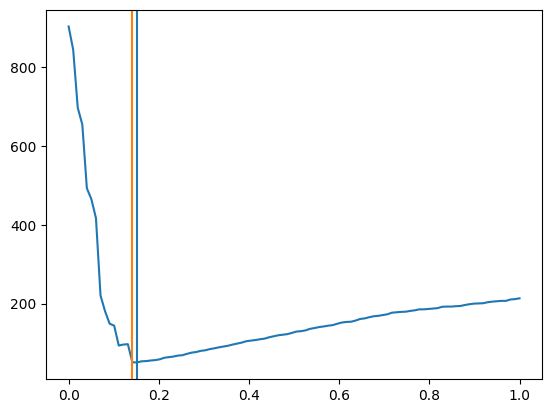

In [39]:
from tqdm.auto import tqdm

eps = 1e-14

cache_a = make_cache(a, b)
cache_b = make_cache(b, a)

lambdas = np.linspace(0, 1, 100)

rankings_a = []
rankings_b = []
rankings_combined = []
for lambda_ in tqdm(lambdas):
#     score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
#     rankings.append(np.argsort(-score).tolist().index(j))

    score_a = npmi_batch_popularity_weighted(mat, a, lambda_, cache=cache_a, eps=eps)
    score_b = npmi_batch_popularity_weighted(mat, b, lambda_, cache=cache_b, eps=eps)
    
    rankings_a.append(np.argsort(-score_a).tolist().index(b))
    rankings_b.append(np.argsort(-score_b).tolist().index(a))
    rankings_combined.append((rankings_a[-1] + rankings_b[-1])/2)

# min(np.diff(rankings))

import matplotlib.pyplot as plt

rankings = rankings_combined

plt.plot(lambdas, rankings);
plt.axvline(lambdas[np.argmin(rankings)]);
plt.axvline(.14, c="tab:orange");

In [32]:
lambdas[np.argmin(rankings)]

np.float64(0.15151515151515152)

In [33]:
min(rankings)

50.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
a_to_b_error_metric_npmi_pop_weighted(artist_mat, a, b, lambda_)

lambda_: 0.13408607326731756
error: 47.5


47.5

In [396]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
#     py = (py * o) + (.5 * (1 - o))
#     px = (px * o) + (.5 * (1 - o))
#     pxy = (pxy * o) + (.5**2 * (1 - o))
#     pxy = (pxy * o) + ((px * py) * (1 - o))

#     px = py = np.where(px > py, px, py)
    px = py = (px + py)/2
#     px = py = px + py

#     px = np.where(px > py, px, py)
#     px = (px + py)/2
#     px = px + py
    
#     py = np.where(px > py, px, py)
#     py = (px + py)/2
#     py = px + py

#     py = np.where(px < py, px, py)
    score = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)

    if call_again:
        return (metric(j, i, o, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [397]:
metric(a, b, .6)

98.5

In [267]:
metric(a, b, .11)

105.0

In [246]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Quiet Arrows (spotify:artist:7KRnRH8bRvoX4ebQwHw2EI)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'This, the Silent War (spotify:artist:3156bBfcG5gFSWrftU8gaR)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Josh Jenkins (spotify:artist:20nyUQUh2kYdqOauF3y3Pu)',
 'Choir Of Young Believers (spotify:artist:4aXPrNXYJLziXeH7Obkea7)',
 'Samaris (spotify:artist:1Xl5hsislt88ijOD3EZsOY)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Adurn (spotify:artist:4hDzPWJ7vNSD2wCEF49w8r)',
 'Joe Banfi (spotify:artist:5XuI2JDHF

In [37]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [33]:
top_k = 20

In [34]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, a, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)',
 'Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)',
 'Mikkel Øwre (spotify:artist:1kNHqkERzDBPrzdK9DogGQ)',
 'Pieces of Juno (spotify:artist:1k88AWvVVqKbz6C0kK624d)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'A-Laget (spotify:artist:2eJz0fbC9ZqBL3mGWPBvI5)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Carl Louis (spotify:artist:5LY4Rzduoz5b0qZdV3rHwK)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Morten Myklebust (spotify:artist:7zFc6IlzgDwyXoj

In [35]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, b, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)',
 'The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'Low Volts (spotify:artist:3PxUwSSsVaW0XyBiRJF2oS)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Panama (spotify:artist:3W9UldYu0xJcaOA